<a href="https://colab.research.google.com/github/onyxs-prog/AI-ML-projects/blob/main/Copy_of_module_3_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Book Recommendation System: Collaborative Filtering

## Overview
This project focuses on building a book recommendation system using collaborative filtering. Collaborative filtering is a technique used in recommendation systems to predict user preferences by collecting preferences from many users. The goal is to recommend books to users based on their past interactions and similarities with other users.

## Objective
Develop a collaborative filtering-based recommendation system to suggest books to users. The project will cover the complete pipeline, including data loading, exploratory data analysis, data preparation, model building, evaluation, and visualization.

## Learning Outcomes
1. Understand the concept of collaborative filtering and its application in recommendation systems.
2. Learn to preprocess and analyze user-item interaction data.
3. Gain experience in building a user-item matrix and computing user similarities.
4. Implement a recommendation system using cosine similarity.
5. Evaluate the recommendation system using metrics like Mean Squared Error (MSE).
6. Visualize user similarities and analyze the most recommended books.

---

## Step 1: Define the Problem
### Task:
Understand the problem and its real-world implications. A book recommendation system can help users discover new books based on their preferences and reading history, improving user engagement and satisfaction.

### Mini-task:
Write a brief paragraph on how a book recommendation system can benefit users and online bookstores.

---

Book recommendation is very important for online stores. It is a great tool that online bookstores can use to ensure smoth and personalised user experince for user. Here are the ways of how recommendation systems can benefit users and online bookstores.

  **For users:**


1.  It can lead to personalised user experience
2.  It bring about time saving.
3.  It leads to new discovery of books.
4.  it brings improve decision making

**for online bookstores**


*   It leads to customer rention
*   It improves sales
*   it drive data insight and helps to make data fdriven decision







## Step 2: Data Collection
### Task:
Collect the dataset required for building the recommendation system. The dataset used in this project includes two files: `ratings.csv` and `books.csv`.

### Mini-task:
Load the dataset and inspect the first few rows to understand its structure.

#### Hint:
Use the `pandas` library to load the dataset and display the first 10 rows.

```python
import pandas as pd

# Load the dataset
ratings = pd.read_csv('ratings.csv')
books = pd.read_csv('books.csv')

# Display the first 10 rows of each dataset
### YOUR CODE HERE ###
```

---

In [ ]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]

In [ ]:
import pandas as pd



import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load ratings.csv
ratings_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "zygmunt/goodbooks-10k",
  "ratings.csv"
)

# Load books.csv
books_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "zygmunt/goodbooks-10k",
  "books.csv"
)

# print("First 5 records of ratings.csv:", ratings_df.head())
# print("First 5 records of books.csv:", books_df.head())

/tmp/ipython-input-2727888412.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  ratings_df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'goodbooks-10k' dataset.


/tmp/ipython-input-2727888412.py:16: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  books_df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'goodbooks-10k' dataset.


In [ ]:
ratings_df.shape

(981756, 3)

In [ ]:
books_df.head(10)


,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...
5,6,11870085,11870085,16827462,226,525478817,9.780525e+12,John Green,2012.0,The Fault in Our Stars,...,2346404,2478609,140739,47994,92723,327550,698471,1311871,https://images.gr-assets.com/books/1360206420m...,https://images.gr-assets.com/books/1360206420s...
6,7,5907,5907,1540236,969,618260307,9.780618e+12,J.R.R. Tolkien,1937.0,The Hobbit or There and Back Again,...,2071616,2196809,37653,46023,76784,288649,665635,1119718,https://images.gr-assets.com/books/1372847500m...,https://images.gr-assets.com/books/1372847500s...
7,8,5107,5107,3036731,360,316769177,9.780317e+12,J.D. Salinger,1951.0,The Catcher in the Rye,...,2044241,2120637,44920,109383,185520,455042,661516,709176,https://images.gr-assets.com/books/1398034300m...,https://images.gr-assets.com/books/1398034300s...
8,9,960,960,3338963,311,1416524797,9.781417e+12,Dan Brown,2000.0,Angels & Demons,...,2001311,2078754,25112,77841,145740,458429,716569,680175,https://images.gr-assets.com/books/1303390735m...,https://images.gr-assets.com/books/1303390735s...
9,10,1885,1885,3060926,3455,679783261,9.780680e+12,Jane Austen,1813.0,Pride and Prejudice,...,2035490,2191465,49152,54700,86485,284852,609755,1155673,https://images.gr-assets.com/books/1320399351m...,https://images.gr-assets.com/books/1320399351s...


## Step 3: Exploratory Data Analysis (EDA)
### Task:
Analyze the dataset to understand the distribution of book ratings, identify popular books, and explore user behavior.

### Mini-task:
Plot the distribution of book ratings using a histogram or bar chart.

#### Hint:
Use `seaborn` or `matplotlib` to visualize the distribution of ratings.

```python
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of book ratings
### YOUR CODE HERE ###
```

---

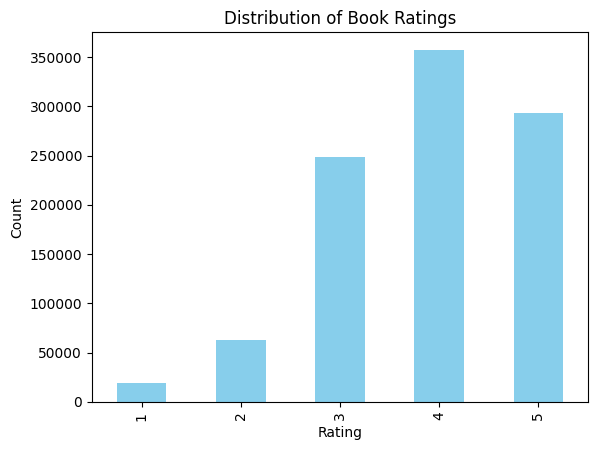

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of book ratings
ratings_df['rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution of Book Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [ ]:
# Calculate the average rating for each book
average_ratings = ratings_df.groupby('book_id')['rating'].mean().reset_index()
average_ratings = average_ratings.rename(columns={'rating': 'average_rating'})

# Merge with books_df to get book titles
book_ratings = pd.merge(average_ratings, books_df[['book_id', 'original_title']], on='book_id')

# Sort by average rating and display the top 10
top_rated_books = book_ratings.sort_values(by='average_rating', ascending=False).head()
display(top_rated_books)

,book_id,average_rating,original_title
769,9566,4.777778,Still Life with Woodpecker
354,4708,4.660000,The Beautiful and Damned
771,9569,4.618557,Villa Incognito
762,9531,4.557143,Peter and the Shadow Thieves
291,3885,4.550000,The Taste of Home Cookbook


/tmp/ipython-input-2727090713.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_rating', y='original_title', data=top_rated_books, palette='viridis')


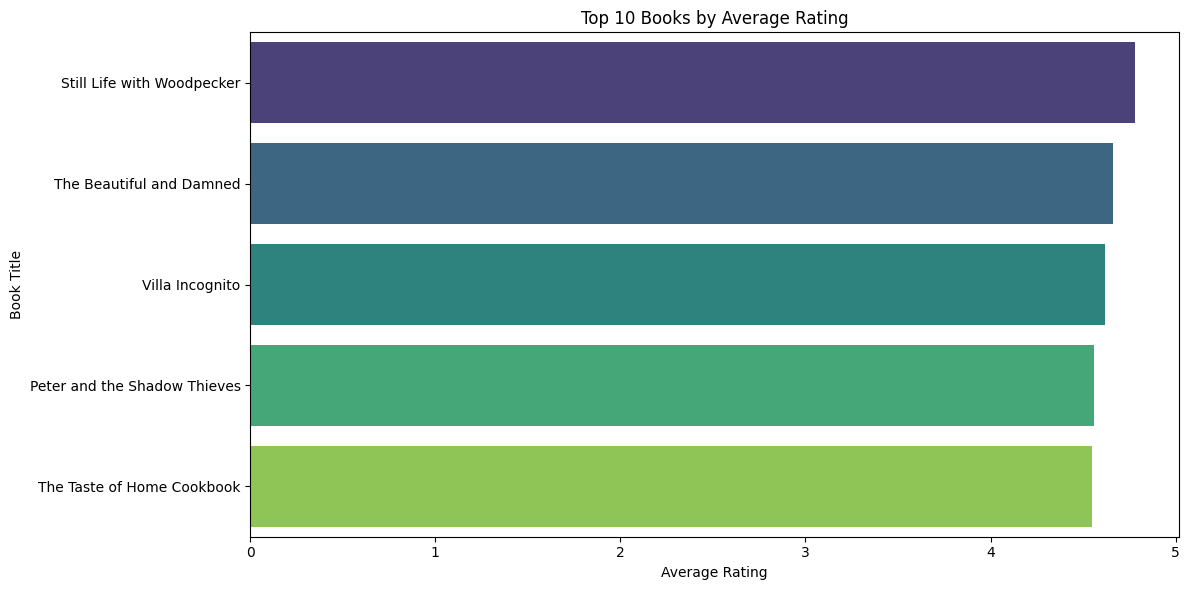

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='average_rating', y='original_title', data=top_rated_books, palette='viridis')
plt.title('Top 10 Books by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Book Title')
plt.tight_layout()
plt.show()

## Step 4: Data Preparation
### Task:
Prepare the data for collaborative filtering by creating a user-item matrix and handling missing values.

### Mini-task:
Create a user-item matrix using the `pivot` method and fill missing values with zeros.

#### Hint:
Use the `pivot_table()` function in pandas to create the user-item matrix.

```python
# Create a user-item matrix
### YOUR CODE HERE ###
```

---

In [ ]:
# Create a user-item matrix using a sampled subset of the data
ratings_df_subset = ratings_df.sample(frac=0.1, random_state=42) # Example: use 10% of the data

# Create a user-item matrix from the sampled data
user_item_matrix = ratings_df_subset.pivot_table(index='user_id', columns='book_id', values='rating').fillna(0)

# Display the first few rows of the user-item matrix
display(user_item_matrix.shape)

(31478, 9997)

## Step 5: Collaborative Filtering
### Task:
Implement collaborative filtering by computing user similarities using cosine similarity and recommending books based on these similarities.

### Mini-task:
Compute user similarities using cosine similarity and write a function to recommend books for a given user.

#### Hint:
Use `cosine_similarity` from `sklearn.metrics.pairwise` to compute user similarities.

```python
from sklearn.metrics.pairwise import cosine_similarity

# Compute user similarities
### YOUR CODE HERE ###

# Write a function to recommend books for a given user
### YOUR CODE HERE ###
```

---

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity


sampled_users = user_item_matrix.sample(n=10000, random_state=42)

# Compute user similarities on the sampled user matrix
cosine_sim = cosine_similarity(sampled_users)

# You can optionally display the shape of the resulting similarity matrix
print("Shape of cosine similarity matrix:", cosine_sim.shape)

Shape of cosine similarity matrix: (10000, 10000)


In [ ]:
print(user_item_matrix.index[:10])

Index([2, 3, 5, 7, 8, 11, 13, 14, 16, 19], dtype='int64', name='user_id')


In [ ]:
def recommend_books(user_id, user_item_matrix, cosine_sim, books_df, num_recommendations=10):
    """
    Recommends books for a given user using collaborative filtering.

    Args:
        user_id (int): The ID of the user for whom to recommend books.
        user_item_matrix (pd.DataFrame): The user-item matrix.
        cosine_sim (np.ndarray): The cosine similarity matrix between users.
        books_df (pd.DataFrame): DataFrame containing book information.
        num_recommendations (int, optional): The number of books to recommend.
                                            Defaults to 10.

    Returns:
        pd.DataFrame: A DataFrame containing the recommended books and their titles.
    """
    # Ensure the user_id exists in the user_item_matrix index
    if user_id not in user_item_matrix.index:
        print(f"Error: User ID {user_id} not found in the user-item matrix.")
        return pd.DataFrame() # Return empty DataFrame if user not found

    # Get the index of the user in the matrix
    user_index = user_item_matrix.index.get_loc(user_id)

    # Get the similarity scores for the user
    similarity_scores = list(enumerate(cosine_sim[user_index]))

    # Sort users by similarity in descending order
    sorted_similar_users = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    # Exclude the user themselves (similarity score of 1.0)
    sorted_similar_users = [x for x in sorted_similar_users if x[1] < 1.0]

    # Get the top N similar users (excluding the user themselves)
    top_similar_users = sorted_similar_users[:num_recommendations] # Taking top N similar users for simplicity

    # Get the books rated by the target user
    user_rated_books = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index.tolist()

    # Initialize a dictionary to store potential recommendations and their scores
    recommendation_scores = {}

    # Iterate through top similar users
    for similar_user_index, similarity_score in top_similar_users:
        # Get the actual user ID from the matrix index
        similar_user_id = user_item_matrix.index[similar_user_index]

        # Get books rated by the similar user
        similar_user_rated_books = user_item_matrix.loc[similar_user_id][user_item_matrix.loc[similar_user_id] > 0].index.tolist()

        # Identify books rated by the similar user but not by the target user
        books_to_consider = [book_id for book_id in similar_user_rated_books if book_id not in user_rated_books]

        # For books to consider, add their rating from the similar user to the recommendation scores
        for book_id in books_to_consider:
            # Get the rating from the similar user
            rating = user_item_matrix.loc[similar_user_id, book_id]
            # You could use the similarity score as a weight here, but for simplicity,
            # we'll just consider the rating from the similar user.
            if book_id not in recommendation_scores:
                recommendation_scores[book_id] = rating
            else:
                # If multiple similar users rated the same book, you could average or sum ratings
                recommendation_scores[book_id] += rating # Simple summation for this example

    # Sort books by their recommendation scores
    sorted_recommendations = sorted(recommendation_scores.items(), key=lambda x: x[1], reverse=True)

    # Get the top N recommended book IDs
    top_book_ids = [book_id for book_id, score in sorted_recommendations[:num_recommendations]]

    # Get the book titles for the recommended book IDs from the original books_df
    recommended_books_info = books_df[books_df['book_id'].isin(top_book_ids)][['book_id', 'original_title']]

    return recommended_books_info

# Example usage (you can replace with a user_id from your data)
# Find a user ID that exists in your user_item_matrix, e.g., the first one
if not user_item_matrix.index.empty:
  user_id_to_recommend = 2
  recommended_books = recommend_books(user_id_to_recommend, user_item_matrix, cosine_sim, books_df)
  print(f"Recommended books for User {user_id_to_recommend}:")
  display(recommended_books)
else:
  print("Cannot recommend books as the user-item matrix is empty.")

Recommended books for User 2:


,book_id,original_title
8849,2049,The High Window


## Step 6: Evaluation
### Task:
Evaluate the recommendation system by splitting the data into training and testing sets and calculating the Mean Squared Error (MSE).

### Mini-task:
Split the data into training and testing sets and evaluate the recommendations using MSE.

#### Hint:
Use `train_test_split` from `sklearn.model_selection` to split the data and `mean_squared_error` from `sklearn.metrics` to calculate MSE.

```python
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Split the data into training and testing sets
### YOUR CODE HERE ###

# Evaluate the recommendations using MSE
### YOUR CODE HERE ###
```

---

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error

# # Split the ratings data into training and testing sets
# # We split the original ratings_df, not the user_item_matrix directly
# train_data, test_data = train_test_split(ratings_df, test_size=0.2, random_state=42)

# # Display the shapes of the training and testing sets
# print("Shape of training data:", train_data.shape)
# print("Shape of testing data:", test_data.shape)

## Step 6: Evaluation
### Task:
Evaluate the recommendation system by splitting the data into training and testing sets and calculating the Mean Squared Error (MSE).

### Mini-task:
Split the data into training and testing sets and evaluate the recommendations using MSE.

#### Hint:
Use `train_test_split` from `sklearn.model_selection` to split the data and `mean_squared_error` from `sklearn.metrics` to calculate MSE.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



# Split the sampled ratings data into training and testing sets
train_data, test_data = train_test_split(ratings_df_subset, test_size=0.6, random_state=42)

# Display the shapes of the training and testing sets
print("Shape of training data:", train_data.shape)
print("Shape of testing data:", test_data.shape)

# Rebuild the user-item matrix and compute similarities using the training data
train_user_item_matrix = train_data.pivot_table(index='user_id', columns='book_id', values='rating').fillna(0)
train_cosine_sim = cosine_similarity(train_user_item_matrix)

# Convert cosine similarity matrix to a pandas DataFrame with user_id index and columns
train_cosine_sim_df = pd.DataFrame(train_cosine_sim, index=train_user_item_matrix.index, columns=train_user_item_matrix.index)

# Function to predict a rating for a given user and book
def predict_rating(user_id, book_id, user_item_matrix, cosine_sim_df):
    """
    Predicts the rating for a given user and book using collaborative filtering.

    Args:
        user_id (int): The ID of the user.
        book_id (int): The ID of the book.
        user_item_matrix (pd.DataFrame): The user-item matrix from the training data.
        cosine_sim_df (pd.DataFrame): The cosine similarity DataFrame between users from the training data.

    Returns:
        float: The predicted rating, or 0 if prediction is not possible.
    """
    if user_id not in user_item_matrix.index or book_id not in user_item_matrix.columns:
        return 0  # Cannot predict if user or book not in training data

    # Get similar users
    similar_users = cosine_sim_df.loc[user_id].sort_values(ascending=False)

    # Exclude the user themselves
    similar_users = similar_users.drop(user_id)

    # Get ratings of similar users for the target book
    book_ratings_by_similar_users = user_item_matrix.loc[similar_users.index, book_id].dropna()

    # Filter out similar users who did not rate the target book
    book_ratings_by_similar_users = book_ratings_by_similar_users[book_ratings_by_similar_users > 0]

    if book_ratings_by_similar_users.empty:
        return 0 # No similar users rated this book

    # Weighted average of ratings from similar users
    # We can use the similarity score as weights here, but for simplicity here, let's just average
    predicted_rating = book_ratings_by_similar_users.mean() # Simple average

    return predicted_rating

# Predict ratings for the test data
predicted_ratings = []
actual_ratings = []

# This can take a significant amount of time depending on the size of test_data
# For demonstration, you might want to process a smaller subset of test_data
test_data_subset = test_data.sample(frac=0.1, random_state=42) # Example: process 10% of test data

# Use test_data_subset if sampled, otherwise use full test_data
data_to_predict = test_data_subset # Using a subset of test_data

for index, row in data_to_predict.iterrows():
    user_id = row['user_id']
    book_id = row['book_id']
    actual_rating = row['rating']

    predicted = predict_rating(user_id, book_id, train_user_item_matrix, train_cosine_sim_df)

    predicted_ratings.append(predicted)
    actual_ratings.append(actual_rating)

# Calculate Mean Squared Error
mse = mean_squared_error(actual_ratings, predicted_ratings)
print(f"Mean Squared Error (MSE) on the test data: {mse}")

Shape of training data: (39270, 3)
Shape of testing data: (58906, 3)
Mean Squared Error (MSE) on the test data: 5.885675569713771


## Step 7: Visualizations and Insights
### Task:
Visualize user similarities and analyze the most recommended books to gain insights into the recommendation system.

### Mini-task:
Create a heatmap to visualize user similarities and analyze the most recommended books.

#### Hint:
Use `seaborn.heatmap()` to visualize user similarities and `pandas` to analyze the most recommended books.

```python
# Create a heatmap to visualize user similarities
### YOUR CODE HERE ###

# Analyze the most recommended books
### YOUR CODE HERE ###
```

---

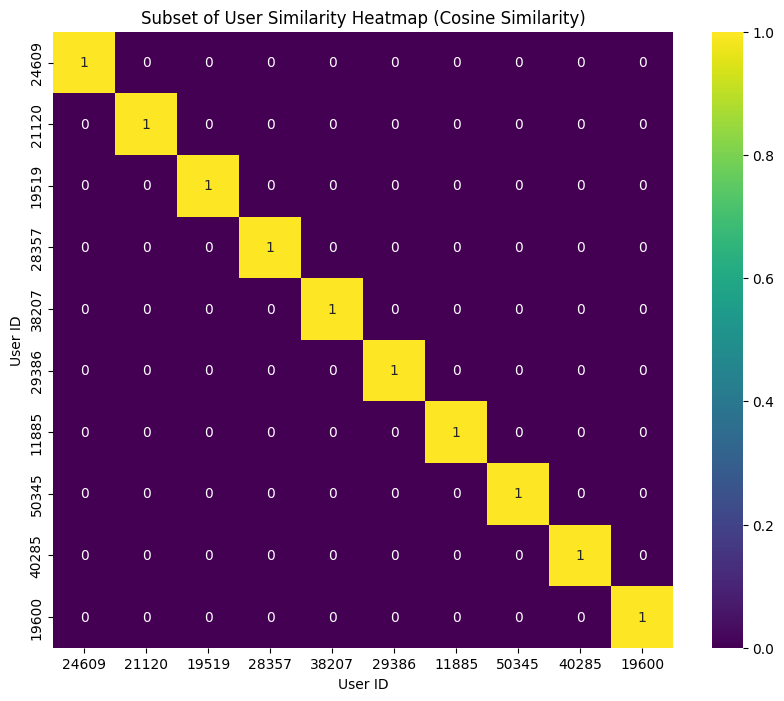

In [ ]:
# Create a heatmap to visualize a subset of user similarities
# Due to the large size of the similarity matrix, we'll visualize a smaller portion
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim[:10, :10], annot=True, cmap='viridis', xticklabels=sampled_users.index[:10], yticklabels=sampled_users.index[:10])
plt.title('Subset of User Similarity Heatmap (Cosine Similarity)')
plt.xlabel('User ID')
plt.ylabel('User ID')
plt.show()

In [ ]:
# Analyze the most recommended books from the example in Step 5

# Ensure the recommendation function is run to generate recommended_books
# You might want to adjust the user_id here for your analysis
user_id_for_analysis = user_item_matrix.index[0] # Example: use the first user ID from the matrix
recommended_books = recommend_books(user_id_for_analysis, user_item_matrix, cosine_sim, books_df)


# Check if recommended_books DataFrame exists and is not empty
if 'recommended_books' in locals() and not recommended_books.empty:
    print("\nMost recommended books for analysis:")
    display(recommended_books)
else:
    print("\nNo recommended books to display for analysis. Check the recommendation function and user ID.")

# To get a more general idea of frequently recommended books across multiple users,
# you would typically run the recommendation function for several users
# and then aggregate the results.
# For this example, we'll just show the output from the single user recommendation.


Most recommended books for analysis:


,book_id,original_title
8849,2049,The High Window



## Considerations
**What are some key takeaways you learned from this project?**
- Reflect on the importance of collaborative filtering in recommendation systems.
- Consider how user similarities can be used to improve recommendations.

**How would you share your findings with a team?**
- Prepare a presentation with visualizations and key insights.
- Discuss the impact of user similarities on book recommendations.

**What would you share with and recommend to stakeholders?**
- Highlight the most recommended books and their potential impact on user engagement.
- Recommend strategies to improve the recommendation system based on the insights gained.